# Place map

In [24]:
import os
import glob
import json
import urllib.request

import pandas as pd
import numpy as np
import openpyxl

from pyproj import Transformer, CRS

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib_scalebar.scalebar import ScaleBar

## Read file

In [25]:
place_data = '/Users/leonm4/Desktop/Oil/LeoOilML'

os.chdir(place_data)

name_xlxs = glob.glob('SAPetroleumWells.xlsx', recursive=True)

df = pd.read_excel(name_xlxs[0])

In [36]:
current_x = [52.370556] #52.370556
current_y = [54.572778] #54.572778

All_x = list(df[df.Security != "Confidential"]["GDA20 X"]) + list(current_x)
All_y = list(df[df.Security != "Confidential"]["GDA20 Y"]) + list(current_y)

## Create map

### Mercators moving

$$
y_{Merc} = R \ln \tan (\dfrac{\pi}{4} + \dfrac{\phi}{2})
$$

$$
y_{plot} = \phi_{min} + (\phi_{max} - \phi_{min}) \dfrac{M(\phi) - M(\phi_{min})}{M(\phi_{max}) - M(\phi_{min})}
$$

$M(\phi)$ - Mercators function

Types of maps for ArcGIS REST API:

1. World_Street_Map
2. World_Imagery
3. World_Topo_Map
4. NatGeo_World_Map
5. World_Terrain_Base
6. World_Shaded_Relief
7. World_Physical_Map
8. Ocean/World_Ocean_Base
9. Canvas/World_Light_Gray_Base
10. Canvas/World_Dark_Gray_Base
11. Reference/World_Boundaries_and_Places
12. Reference/World_Transportation

List of services:
1. Australian_Geological_Provinces (Geoscience Australia): services.ga.gov.au (/gis/rest/services/, Australian_Geological_Provinces)
2. Asia_Pacific_Geology (USGS): services.arcgis.com (/v01gqwM5QqNysAAi/arcgis/rest/services/, Asia_Pacific_Geology)
3. Middle_East/Geology_and_Tectonics: www.ufz.de
4. Connecticut_Bedrock_Geology (CT DEEP): services1.arcgis.com

In [30]:
ll2merc = Transformer.from_crs(4326, 3857, always_xy=True)
merc2ll = Transformer.from_crs(3857, 4326, always_xy=True)
MERC_LAT_LIM = 85.05112878

def lonlat_to_merc(lon, lat):
    return ll2merc.transform(lon, lat)

def merc_to_lonlat(x, y):
    return merc2ll.transform(x, y)

In [31]:
def create_map(
        X,
        Y,
        auto_scale = True,
        lon_min = -180.0,
        lat_min = -MERC_LAT_LIM,
        lon_max = 180.0,
        lat_max = MERC_LAT_LIM,
        system = 3857, #EPSG
        length = 1200,
        height = 800,
        map_services = "arcgisonline.com/arcgis/rest/services/",
        map_type = "NatGeo_World_Map",
        name_map = "map.png",
        Title = "Map",
        Legend = "",
        scalebar = True,
        #point_size = 8,
        point_color = "orange",
        edge_color = "black",
        edge_width = 2.0,
        alpha = 0.8,
        zorder_points = 5,
        xlabel = "Longitude, degrees",
        ylabel = "Latitude, degrees",
        save = False
):
    if auto_scale:
        pad = 0.3
        lon_min, lon_max = min(X) - pad, max(X) + pad
        lat_min, lat_max = min(Y) - pad, max(Y) + pad

    lat_min = max(lat_min, -MERC_LAT_LIM)
    lat_max = min(lat_max, MERC_LAT_LIM)

    if len(X) == 0 or len(Y) == 0:
        if auto_scale:
            lon_min, lon_max = -180.0, 180.0
            lat_min, lat_max = -MERC_LAT_LIM, MERC_LAT_LIM
        Xp = Yp = np.array([])
    else:
        Xp, Yp = lonlat_to_merc(np.asarray(X), np.asarray(Y))

    span = max(lon_max - lon_min, lat_max - lat_min)
    cluster = max(np.ptp(X), np.ptp(Y)) if len(X) else 1
    ratio = span / max(cluster, 1e-9)
    point_size = max(6, min(60, 6 * np.sqrt(ratio)))

    x0, y0 = lonlat_to_merc(lon_min, lat_min)
    x1, y1 = lonlat_to_merc(lon_max, lat_max)

    geo_ratio = (x1 - x0) / (y1 - y0)
    height = max(200, int(round(length / geo_ratio)))

    URL_map = (f"https://services.{map_services}"
               f"{map_type}/MapServer/export?"
               f"bbox={x0},{y0},{x1},{y1}"
               f"&bboxSR={system}"
               f"&imageSR={system}"
               f"&size={length},{height}"
               f"&format=png32"
               f"&f=json"
               )

    with urllib.request.urlopen(URL_map) as r:
        meta = json.load(r)
    ext = meta["extent"]
    x_min, x_max, y_min, y_max = ext["xmin"], ext["xmax"], ext["ymin"], ext["ymax"]
    extent = [x_min, x_max, y_min, y_max]
    actual_sr = ext.get("spatialReference", {}).get("wkid")
    urllib.request.urlretrieve(meta["href"], name_map)

    img = mpimg.imread(name_map)

    if actual_sr not in (3857, 102100, 10213, None):
        raise RuntimeError(f"Unsupported spatial reference: {actual_sr}")

    fig, ax = plt.subplots(figsize=(12, 12 / geo_ratio))

    ax.imshow(img, extent=extent, origin="upper", zorder=1)
    ax.scatter(Xp, Yp,
               c=point_color, s=point_size,
               edgecolors=edge_color, linewidths=edge_width,
               zorder=zorder_points, alpha=alpha)

    ax.set_aspect("equal", adjustable="box")
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

    ax.set_title(Title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    if Legend != "":
        ax.legend(Legend, loc="upper left")

    lons = np.linspace(lon_min, lon_max, 7)
    lats = np.linspace(lat_min, lat_max, 7)
    tx, _ = lonlat_to_merc(lons, np.zeros_like(lons))
    _, ty = lonlat_to_merc(np.zeros_like(lats), lats)
    ax.set_xticks(tx)
    ax.set_yticks(ty)
    ax.set_xticklabels([f"{v:.0f}" for v in lons])
    ax.set_yticklabels([f"{v:.0f}" for v in lats])



    if scalebar:
        mid_lat = (lat_min + lat_max) / 2
        dx_scale = np.cos(np.radians(mid_lat))
        ax.add_artist( ScaleBar(dx_scale, units="m",
                                location="lower left",
                                length_fraction=0.25,
                                box_alpha=0.7, color="black"))

    if save:
        plt.savefig(name_map, dpi=400, bbox_inches='tight', transparent=True)

    plt.show()

    return fig, ax

### World map

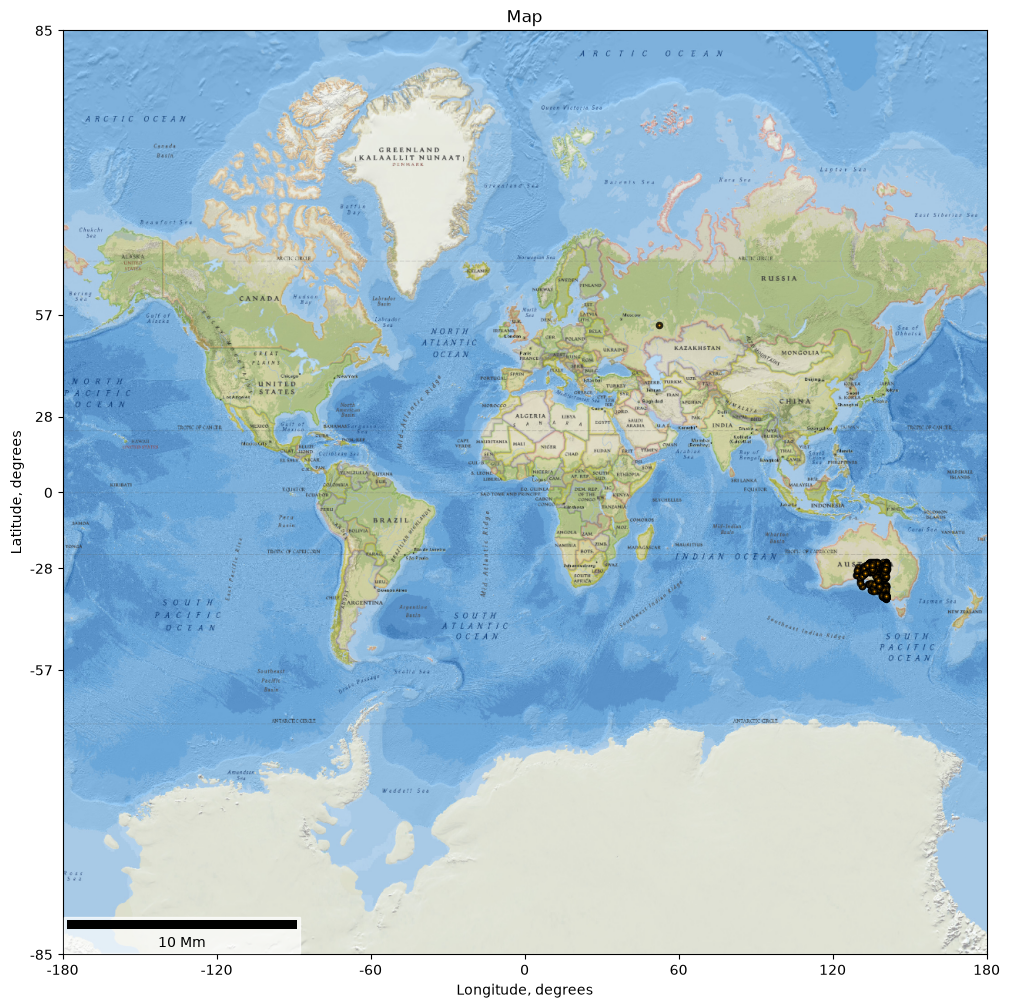

(<Figure size 1200x1200 with 1 Axes>,
 <Axes: title={'center': 'Map'}, xlabel='Longitude, degrees', ylabel='Latitude, degrees'>)

In [39]:
create_map(All_x, All_y, auto_scale=False,
           name_map="Picture/World_data",
           save=True
            )

## Australian data

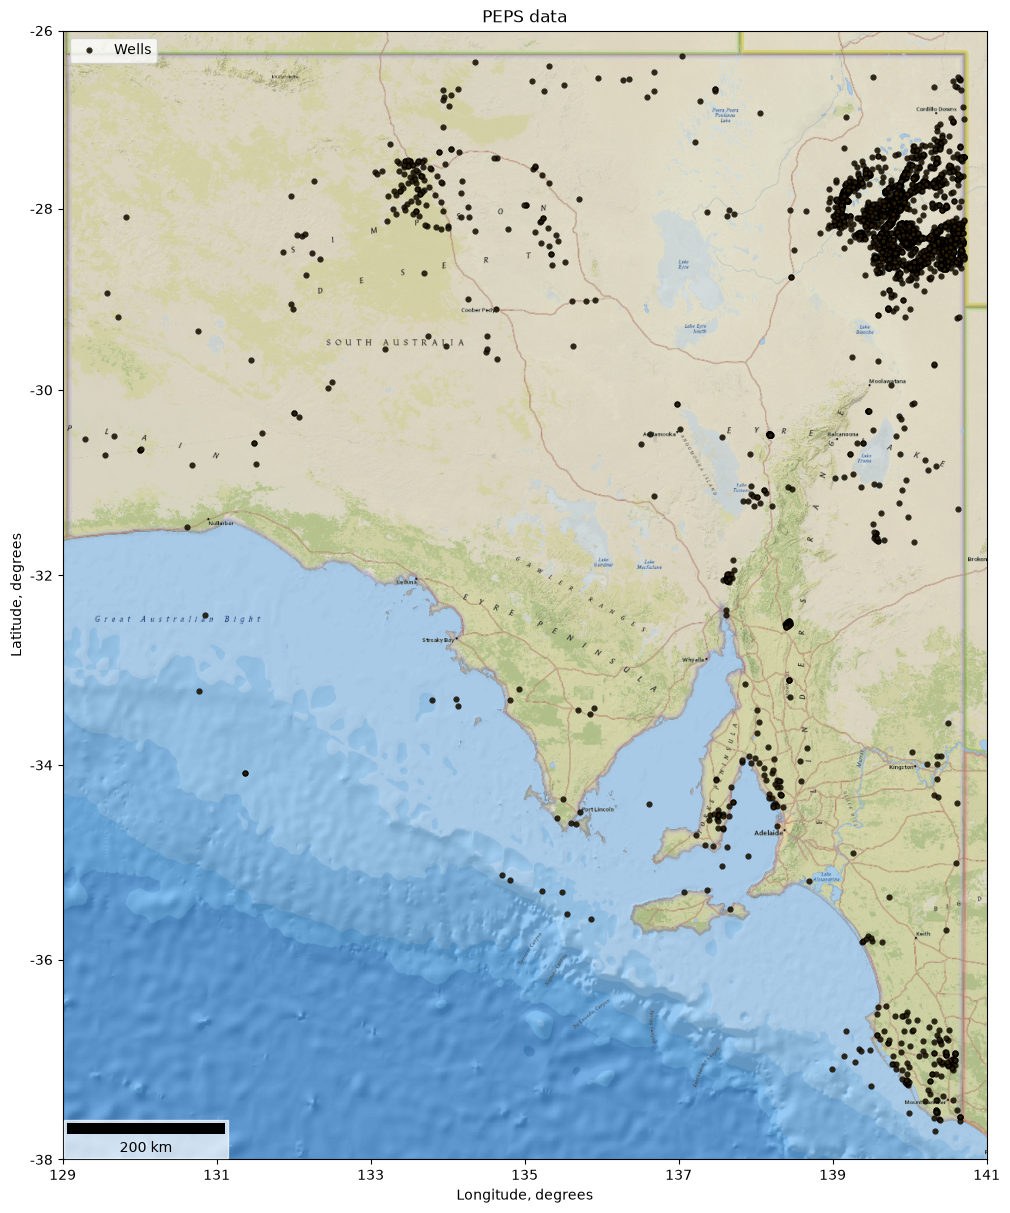

(<Figure size 1200x1466.08 with 1 Axes>,
 <Axes: title={'center': 'PEPS data'}, xlabel='Longitude, degrees', ylabel='Latitude, degrees'>)

In [33]:
create_map(df[df.Security != "Confidential"]["GDA20 X"],
           df[df.Security != "Confidential"]["GDA20 Y"],
           name_map="Picture/Australia_new.png", Legend=["Wells"], Title="PEPS data",
           save=True
           )

## Romashkino

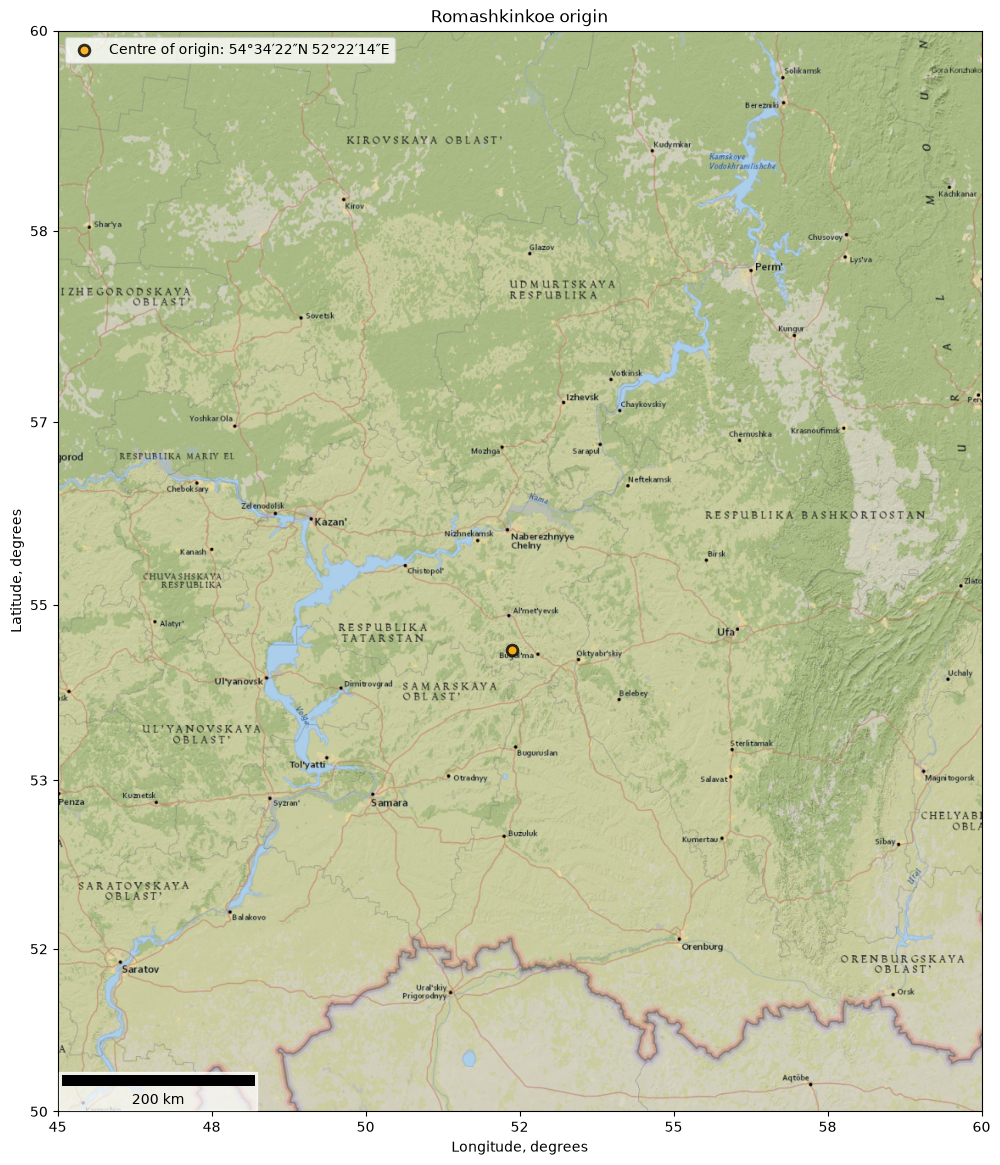

(<Figure size 1200x1403.86 with 1 Axes>,
 <Axes: title={'center': 'Romashkinkoe origin'}, xlabel='Longitude, degrees', ylabel='Latitude, degrees'>)

In [37]:
create_map(current_x, current_y, auto_scale=False, Title="Romashkinkoe origin",
           Legend=["Centre of origin: 54°34′22″N 52°22′14″E"],
           lon_min=45, lat_min=50, lon_max=60, lat_max=60,
           name_map="Picture/Romashkino_new.png",
           save=True
           )
# X = 54.572778
# Y = 52.370556